# GWP1 — Student A Contribution
## Macroeconomic / Geopolitical Variables, Outlier Screening, Distributional Analysis

**MScFE 660 Risk Management · Group Work Project 1 · Student A: Seungeun Park**

This notebook covers only the tasks assigned to Student A:

| Step | Student A task |
|---|---|
| 3 | Identify, import, structure and graph the **macroeconomic and geopolitical** variables (broad U.S. dollar index; Caldara–Iacoviello GPR index) |
| 5 | **Extreme-outlier** screening, applied to *all* series collected by the group |
| 7 | **Distributional** plots, for *all* datasets |
| 9 | Summary of **probabilistic graphical models** — belief networks vs Markov networks |

The group panel (WTI, Brent, dollar, VIX, inventories, GPR; monthly,
2006-02 to 2025-12, 239 observations) is loaded from `data/`. Sources: EIA-based
oil price files, FRED `TWEXBGSMTH`, CBOE VIX monthly file, EIA `WCESTUS1`,
and the Caldara–Iacoviello geopolitical risk index.

### 0 · Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({"figure.autolayout": True, "axes.grid": True,
                     "grid.alpha": .3, "font.size": 11})
DATA, FIG = "data", "figures"

panel = pd.read_csv(f"{DATA}/gwp1_augmented_panel_model_with_gpr.csv",
                    parse_dates=["Date"]).set_index("Date")
print(panel.shape, "| sample:", panel.index.min().date(), "->", panel.index.max().date())
panel.head(3)

(239, 19) | sample: 2006-02-28 -> 2025-12-31


,Month,WTI,Brent,DollarIndex,VIX,CrudeStocks,WTI_ret,Brent_ret,DollarIndex_ret,VIX_change,Inventory_change,Brent_WTI_spread,Spread_change,WTI_lag1,Rolling_vol_6m,GPR,GPR_change,MonthNum,MonthName
Date,,,,,,,,,,,,,,,,,,,
2006-02-28,2006-02,61.63,60.21,100.2112,12.34,309132.75,-0.060749,-0.045138,0.002110,-0.61,5167.75,-1.42,1.08,0.097435,0.063451,95.858192,1.348175,2,Feb
2006-03-31,2006-03,62.69,62.06,100.4281,11.39,323092.80,0.017053,0.030263,0.002162,-0.95,13960.05,-0.63,0.79,-0.060749,0.063977,92.797623,-3.060570,3,Mar
2006-04-30,2006-04,69.44,70.26,99.7435,11.59,329308.25,0.102261,0.124101,-0.006840,0.20,6215.45,0.82,1.45,0.017053,0.072888,89.015800,-3.781822,4,Apr


### 1 · Step 3 — Macroeconomic and geopolitical variables (Student A's own series)

Student A is responsible for the two non-market drivers in the group panel.

* **Broad U.S. dollar index** (FRED `TWEXBGSMTH`, macroeconomic). Crude oil is
  priced in dollars, so a stronger dollar mechanically pressures the barrel.
  The raw index starts in January 2006, which is what fixes the group's core
  sample at 2006-02 onward.
* **Geopolitical Risk index** (Caldara–Iacoviello, geopolitical). A news-based
  count of war, terror and sanction coverage. Available from 1985, so its full
  history is shown first before it is cut to the core sample.

Both raw series are imported below, structured to the monthly grid, and graphed
in levels and in monthly changes.

dollar raw: 2006-01-01 -> 2026-06-01 246 rows
GPR raw:    1985-01-31 -> 2026-06-30 498 rows


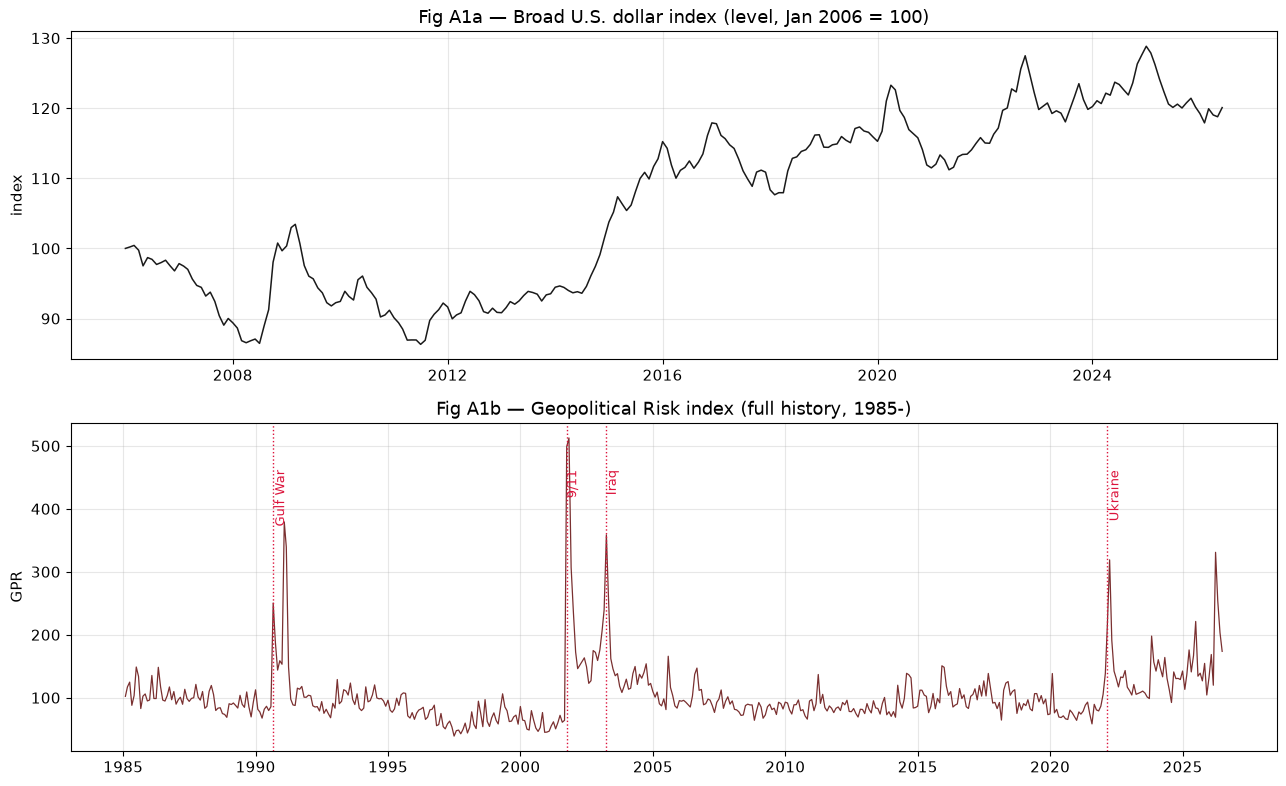

In [2]:
usd_raw = pd.read_csv(f"{DATA}/TWEXBGSMTH_monthly.csv", parse_dates=["Date"]).set_index("Date")
gpr_raw = pd.read_csv(f"{DATA}/GPR_monthly.csv", parse_dates=["Date"]).set_index("Date")
print("dollar raw:", usd_raw.index.min().date(), "->", usd_raw.index.max().date(), len(usd_raw), "rows")
print("GPR raw:   ", gpr_raw.index.min().date(), "->", gpr_raw.index.max().date(), len(gpr_raw), "rows")

fig, ax = plt.subplots(2, 1, figsize=(13, 8))
ax[0].plot(usd_raw.index, usd_raw["DollarIndex"], color="#1a1a1a", lw=1.1)
ax[0].set(title="Fig A1a — Broad U.S. dollar index (level, Jan 2006 = 100)", ylabel="index")
ax[1].plot(gpr_raw.index, gpr_raw["GPR"], color="#7a3030", lw=.9)
for d, lab in [("1990-08-31", "Gulf War"), ("2001-09-30", "9/11"),
               ("2003-03-31", "Iraq"), ("2022-02-28", "Ukraine")]:
    ax[1].axvline(pd.Timestamp(d), color="crimson", ls=":", lw=1)
    ax[1].text(pd.Timestamp(d), gpr_raw["GPR"].max()*.9, lab, rotation=90,
               color="crimson", fontsize=9, va="top")
ax[1].set(title="Fig A1b — Geopolitical Risk index (full history, 1985-)", ylabel="GPR")
plt.savefig(f"{FIG}/figA1_macro_geo_levels.png", dpi=130); plt.show()

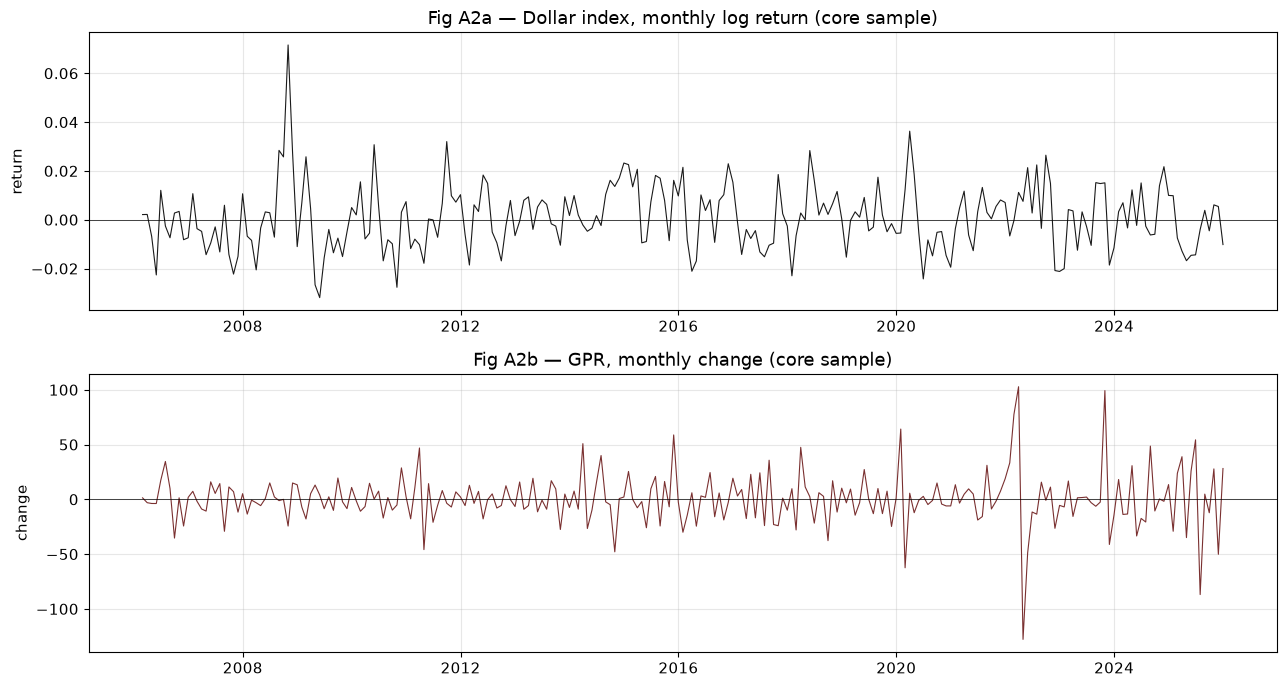

core-sample correlation with WTI return:
  dollar return: -0.444
  GPR level    : -0.011


In [3]:
# structure: align to the core monthly panel and transform to changes
core = panel[["DollarIndex_ret", "GPR", "GPR_change"]].copy()
fig, ax = plt.subplots(2, 1, figsize=(13, 7))
ax[0].plot(core.index, core["DollarIndex_ret"], color="#1a1a1a", lw=.8)
ax[0].axhline(0, color="k", lw=.5)
ax[0].set(title="Fig A2a — Dollar index, monthly log return (core sample)", ylabel="return")
ax[1].plot(core.index, core["GPR_change"], color="#7a3030", lw=.8)
ax[1].axhline(0, color="k", lw=.5)
ax[1].set(title="Fig A2b — GPR, monthly change (core sample)", ylabel="change")
plt.savefig(f"{FIG}/figA2_macro_geo_changes.png", dpi=130); plt.show()

print("core-sample correlation with WTI return:")
print("  dollar return:", round(panel["WTI_ret"].corr(panel["DollarIndex_ret"]), 3))
print("  GPR level    :", round(panel["WTI_ret"].corr(panel["GPR"]), 3))

The dollar shows the expected inverse link with WTI returns (about −0.44 in the
core sample). The GPR series is spiky rather than trending: it jumps on discrete
events and decays back. That behaviour is exactly why it enters the group model
as a discretized state variable rather than as a smooth regressor.

### 2 · Step 5 — Extreme-outlier screening (applied to ALL series)

Student A's cleaning lens is the extreme-outlier check, run on every transformed
series in the group panel, not only on the two macro/geopolitical ones.

Method: a **modified z-score** built on the median and the median absolute
deviation (MAD). Median-based statistics are not dragged around by the outliers
they are trying to find, which is the problem with a plain mean/std z-score.
A month is *flagged* when |z| exceeds 5. Flagged months are **reviewed, not
deleted**: in oil data the extreme observations are usually real stress events
(2008, 2020), and deleting them would remove exactly what a risk model needs.

In [4]:
SERIES = ["WTI_ret", "Brent_ret", "DollarIndex_ret", "VIX_change",
          "Inventory_change", "GPR_change"]

def robust_z(s):
    med = s.median()
    mad = (s - med).abs().median()
    return 0.6745 * (s - med) / mad

flags = []
for c in SERIES:
    z = robust_z(panel[c].dropna())
    hit = z[z.abs() > 5]
    for d, v in hit.items():
        flags.append([d.strftime("%Y-%m"), c, round(panel.loc[d, c], 4), round(v, 2)])

flag_tab = (pd.DataFrame(flags, columns=["Month", "Series", "Value", "Robust z"])
              .sort_values(["Series", "Month"]).reset_index(drop=True))
flag_tab.to_csv(f"{DATA}/studentA_outlier_flags.csv", index=False)
print(f"{len(flag_tab)} flagged observations across {len(SERIES)} series")
flag_tab

15 flagged observations across 6 series


,Month,Series,Value,Robust z
0,2020-03,Brent_ret,-0.5532,-6.68
1,2020-04,Brent_ret,-0.5548,-6.70
2,2020-05,Brent_ret,0.4691,5.42
3,2008-10,DollarIndex_ret,0.0716,5.92
4,2022-03,GPR_change,102.7959,6.57
5,2022-04,GPR_change,-127.8118,-8.06
6,2023-10,GPR_change,99.2522,6.35
7,2025-07,GPR_change,-86.9129,-5.47
8,2008-09,VIX_change,18.7400,5.28
9,2008-10,VIX_change,20.5000,5.77


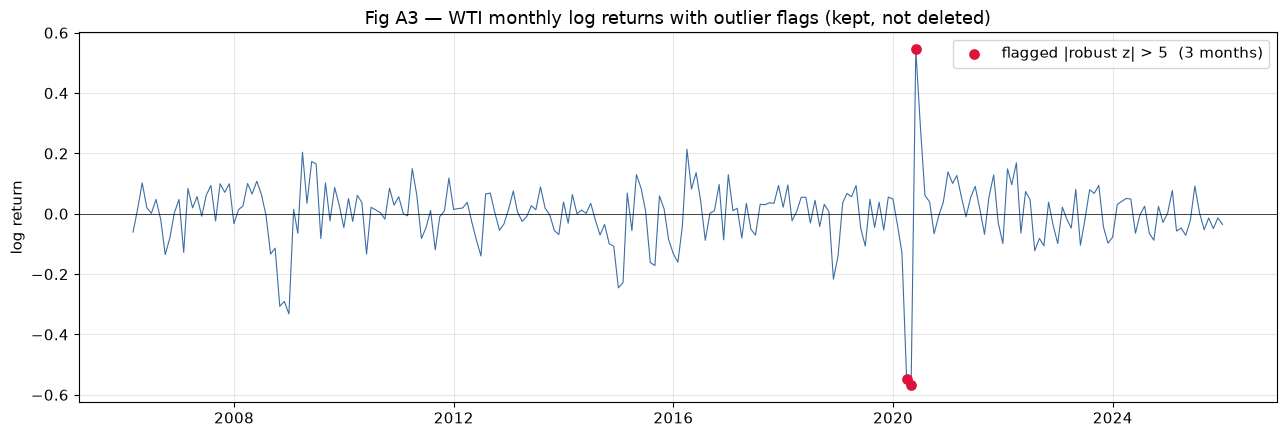

In [5]:
# visualise the flags on the target series
r = panel["WTI_ret"]
z = robust_z(r)
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(r.index, r, color="#3b6ea5", lw=.8)
ext = r[z.abs() > 5]
ax.scatter(ext.index, ext, color="crimson", zorder=5, s=45,
           label=f"flagged |robust z| > 5  ({len(ext)} months)")
ax.axhline(0, color="k", lw=.5)
ax.set(title="Fig A3 — WTI monthly log returns with outlier flags (kept, not deleted)",
       ylabel="log return")
ax.legend()
plt.savefig(f"{FIG}/figA3_outlier_flags.png", dpi=130); plt.show()

Every flag lands on a recognisable market event — the 2020 pandemic collapse and
rebound dominate, with 2008 close behind. None of them look like data errors
(no isolated ten-fold jumps, no impossible signs), so the recommendation to the
group is to keep all flagged months and let Student B's bad-data check and
Student C's missing-value treatment handle the mechanical problems.

### 3 · Step 7 — Distributional plots (for ALL datasets)

Student A's EDA lens is the shape of each variable's distribution. Two views:
a histogram grid across the whole panel, then a closer look at the target.

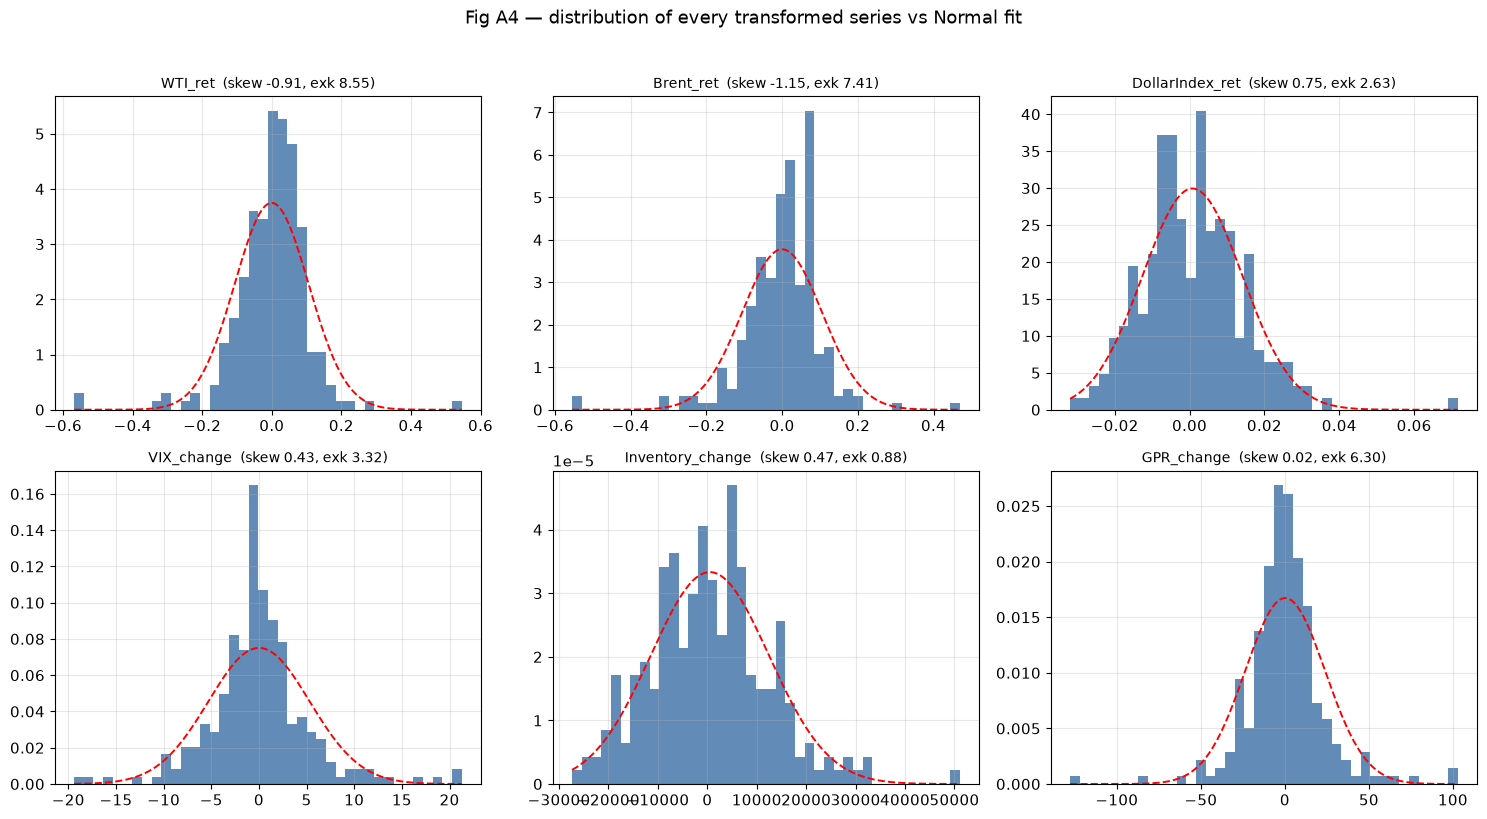

,mean,std,skew,excess kurtosis,min,max
WTI_ret,-0.0005,0.1065,-0.9073,8.5528,-0.5681,0.5456
Brent_ret,-0.0000,0.1056,-1.1488,7.4128,-0.5548,0.4691
DollarIndex_ret,0.0008,0.0133,0.7456,2.6345,-0.0319,0.0716
VIX_change,0.0084,5.3159,0.4258,3.3223,-19.3900,21.2700
Inventory_change,504.1402,11969.0254,0.4669,0.8834,-27361.7500,51046.5000
GPR_change,0.1589,23.8567,0.0156,6.3015,-127.8118,102.7959


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.ravel(), SERIES):
    s = panel[c].dropna()
    ax.hist(s, bins=40, density=True, color="#3b6ea5", alpha=.8)
    x = np.linspace(s.min(), s.max(), 300)
    ax.plot(x, stats.norm.pdf(x, s.mean(), s.std()), "r--", lw=1.4)
    ax.set_title(f"{c}  (skew {s.skew():.2f}, exk {s.kurt():.2f})", fontsize=10)
fig.suptitle("Fig A4 — distribution of every transformed series vs Normal fit", y=1.02)
plt.savefig(f"{FIG}/figA4_distribution_grid.png", dpi=130, bbox_inches="tight"); plt.show()

summ = pd.DataFrame({c: {"mean": panel[c].mean(), "std": panel[c].std(),
                         "skew": panel[c].skew(), "excess kurtosis": panel[c].kurt(),
                         "min": panel[c].min(), "max": panel[c].max()}
                     for c in SERIES}).T.round(4)
summ.to_csv(f"{DATA}/studentA_distribution_summary.csv")
summ

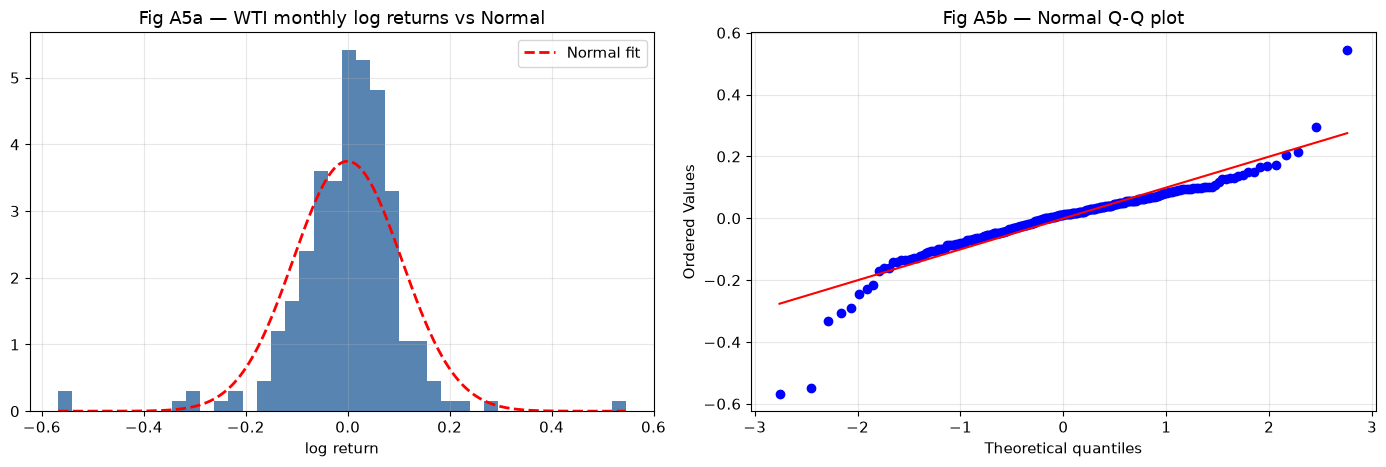

WTI: skew -0.91, excess kurtosis 8.55, Jarque-Bera p = 1.59e-158


In [7]:
r = panel["WTI_ret"].dropna()
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
ax[0].hist(r, bins=40, density=True, color="#3b6ea5", alpha=.85)
x = np.linspace(r.min(), r.max(), 400)
ax[0].plot(x, stats.norm.pdf(x, r.mean(), r.std()), "r--", lw=2, label="Normal fit")
ax[0].set(title="Fig A5a — WTI monthly log returns vs Normal", xlabel="log return")
ax[0].legend()
stats.probplot(r, dist="norm", plot=ax[1])
ax[1].set_title("Fig A5b — Normal Q-Q plot")
plt.savefig(f"{FIG}/figA5_wti_distribution.png", dpi=130); plt.show()
print(f"WTI: skew {r.skew():.2f}, excess kurtosis {r.kurt():.2f}, "
      f"Jarque-Bera p = {stats.jarque_bera(r).pvalue:.2e}")

Reading the grid: every market series is fat-tailed relative to its Normal fit,
and the target is the worst offender — WTI returns carry negative skew (≈ −0.91)
and excess kurtosis near 8.6, and the Q-Q plot bends away from the line at both
ends. GPR changes are heavy-tailed in the *positive* direction (risk spikes up
faster than it decays), while inventory changes are the closest to Normal. The
practical conclusion for the group: no Gaussian assumption survives this panel,
which supports the move to discretized states in the Bayesian-network stage.

### 4 · Step 9 — Probabilistic graphical models: belief networks vs Markov networks

**What a PGM is.** A probabilistic graphical model represents a joint probability
distribution with a graph: nodes are random variables, edges are direct
dependencies, and a missing edge is a statement of conditional independence.
That missing-edge property is the whole point — it factorises a joint
distribution that would otherwise be too large to estimate into small local
pieces, and it makes the model's assumptions visible enough to argue with.

**Belief network (Bayesian network).** Directed and acyclic. Each node carries a
conditional probability table given its parents, and the joint factorises as the
product of those tables. Direction lets the graph express asymmetric statements
("a GPR spike raises the probability of an extreme oil month") and supports
evidence updating: observe some nodes, read off the conditional distribution of
the target. That is the natural fit for this project, where the question is how
the WTI return state responds to observed driver states.

**Markov network (Markov random field).** Undirected. Edges represent symmetric
association, the joint factorises over cliques through potential functions, and
a normalising constant (the partition function) is needed. It is the right tool
for mutual, direction-free dependence — spatial data, contemporaneous
co-movement — but it cannot say which way an influence runs.

**Why the group uses a belief network.** The assignment centres on inferred
causal structure and scenario updating, both of which need directed edges. The
undirected view is still useful as the skeleton the structure-learning stage
works on before edges are oriented — which is exactly how the group's
inferred-causality pseudocode (Step 10) proceeds.

---
*Hand-off notes.* Outlier flags are in `data/studentA_outlier_flags.csv` for
Student B's bad-data pass; distribution summaries are in
`data/studentA_distribution_summary.csv`. All figures regenerate by running this
notebook top to bottom.